# Exercícios — Regressão Linear

**Tema:** Aprendizado Supervisionado › Regressão Linear

Resolva antes de olhar o gabarito. **Dificuldade:** 🟢 base · 🟡 aplicação ·
🔴 síntese

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score

rng = np.random.default_rng(700)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("ambiente pronto")

ambiente pronto


---
## Exercício 1 🟢 — Interpretando um coeficiente

Um modelo ajusta `salario = 2000 + 350*anos_experiencia + 800*tem_mestrado`
(`tem_mestrado` é 0/1). Interprete, em uma frase cada, os três coeficientes.
Depois calcule o salário previsto para alguém com 5 anos de experiência e
sem mestrado.

In [2]:
# --- sua resposta ---

### Gabarito 1

In [3]:
intercepto, coef_experiencia, coef_mestrado = 2000, 350, 800
anos, mestrado = 5, 0
previsto = intercepto + coef_experiencia * anos + coef_mestrado * mestrado
print(f"salário previsto: {previsto}")

print("""
Interpretação:
- intercepto (2000): salário previsto para alguém com 0 anos de experiência
  e sem mestrado (a origem do modelo, nem sempre um caso real observável).
- coef_experiencia (350): a cada ano adicional de experiência, o salário
  previsto sobe 350, mantendo a posse de mestrado constante.
- coef_mestrado (800): ter mestrado soma 800 ao salário previsto, mantendo
  os anos de experiência constantes.
""")

salário previsto: 3750

Interpretação:
- intercepto (2000): salário previsto para alguém com 0 anos de experiência
  e sem mestrado (a origem do modelo, nem sempre um caso real observável).
- coef_experiencia (350): a cada ano adicional de experiência, o salário
  previsto sobe 350, mantendo a posse de mestrado constante.
- coef_mestrado (800): ter mestrado soma 800 ao salário previsto, mantendo
  os anos de experiência constantes.



---
## Exercício 2 🟢 — R² vs. R² ajustado

Gere `y` a partir de uma única feature real. Ajuste um modelo só com ela, e
outro adicionando 10 features de ruído puro. Compare R² e R² ajustado dos
dois modelos.

In [4]:
# --- sua resposta ---

### Gabarito 2

In [5]:
n = 200
x_real = rng.normal(0, 1, n)
y = 3 + 2 * x_real + rng.normal(0, 1, n)
ruido = rng.normal(0, 1, (n, 10))


def r2_e_r2_ajustado(X, y):
    modelo = LinearRegression().fit(X, y)
    r2 = modelo.score(X, y)
    n_obs, p = X.shape
    r2_aj = 1 - (1 - r2) * (n_obs - 1) / (n_obs - p - 1)
    return r2, r2_aj


r2_simples, r2_aj_simples = r2_e_r2_ajustado(x_real.reshape(-1, 1), y)
X_com_ruido = np.column_stack([x_real, ruido])
r2_ruido, r2_aj_ruido = r2_e_r2_ajustado(X_com_ruido, y)

print(f"só a feature real   : R²={r2_simples:.4f}   R² ajustado={r2_aj_simples:.4f}")
print(f"+ 10 features ruído : R²={r2_ruido:.4f}   R² ajustado={r2_aj_ruido:.4f}")

só a feature real   : R²=0.8215   R² ajustado=0.8206
+ 10 features ruído : R²=0.8313   R² ajustado=0.8215


**Resposta esperada:** R² sobe (ou no mínimo não cai) com as features de
ruído. R² ajustado deve subir bem menos, ou até cair — ele penaliza pelo
número de parâmetros e não recompensa "ajuste" que não vem de sinal real.

---
## Exercício 3 🟡 — Diagnosticando um caso de não-linearidade disfarçada

Gere `y = 5 + 3*log(x) + ruído` para `x` positivo. Ajuste uma regressão
linear simples de `y` em `x` (sem transformar). Produza o gráfico
resíduo-vs-previsto e identifique o padrão. Depois ajuste `y` em `log(x)` e
compare os dois diagnósticos.

In [6]:
# --- sua resposta ---

### Gabarito 3

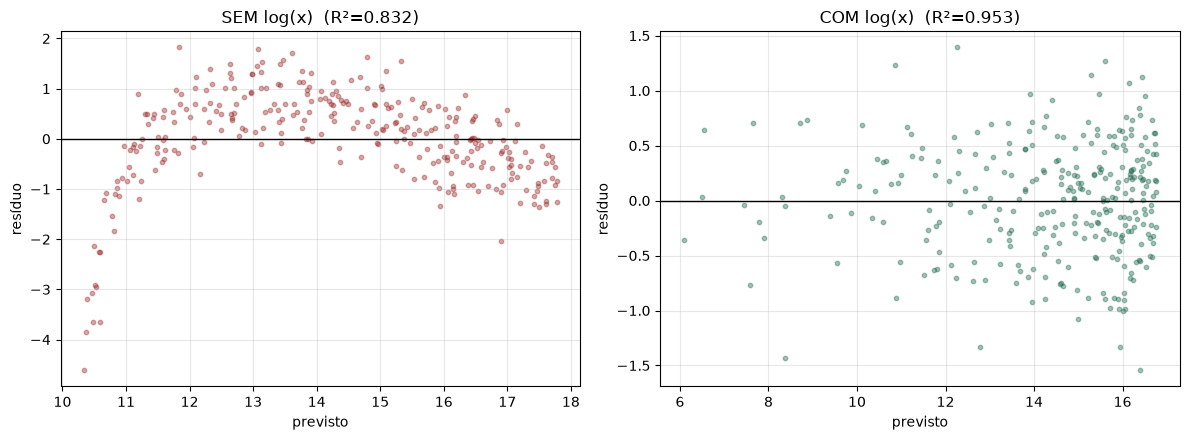

In [7]:
x = rng.uniform(1, 50, 300)
y = 5 + 3 * np.log(x) + rng.normal(0, 0.5, 300)

modelo_sem_log = LinearRegression().fit(x.reshape(-1, 1), y)
pred_sem_log = modelo_sem_log.predict(x.reshape(-1, 1))
res_sem_log = y - pred_sem_log

modelo_com_log = LinearRegression().fit(np.log(x).reshape(-1, 1), y)
pred_com_log = modelo_com_log.predict(np.log(x).reshape(-1, 1))
res_com_log = y - pred_com_log

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(pred_sem_log, res_sem_log, s=10, alpha=0.4, color=VERMELHO)
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title(f"SEM log(x)  (R²={modelo_sem_log.score(x.reshape(-1,1), y):.3f})")
axes[1].scatter(pred_com_log, res_com_log, s=10, alpha=0.4, color=VERDE)
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title(f"COM log(x)  (R²={modelo_com_log.score(np.log(x).reshape(-1,1), y):.3f})")
for ax in axes:
    ax.set_xlabel("previsto"); ax.set_ylabel("resíduo")
plt.tight_layout(); plt.show()

**Resposta esperada:** sem transformar, o resíduo mostra um padrão curvo
sistemático (o modelo linear não acompanha a curva logarítmica). Com
`log(x)` como feature, o padrão deve desaparecer e o R² deve subir
nitidamente — a transformação certa aqui não é no alvo, é na feature.

---
## Exercício 4 🟡 — Multicolinearidade e instabilidade de coeficientes

Gere duas features com correlação de 0,97 entre si, ambas com efeito real
no alvo. Ajuste o modelo 50 vezes em reamostragens bootstrap dos dados e
reporte o desvio-padrão dos dois coeficientes. Repita com features
independentes e compare a estabilidade.

In [8]:
# --- sua resposta ---

### Gabarito 4

In [9]:
def experimento_colinearidade(correlacao, n=300, repeticoes=50):
    z = rng.normal(0, 1, n)
    x1 = correlacao * z + np.sqrt(1 - correlacao**2) * rng.normal(0, 1, n)
    x2 = correlacao * z + np.sqrt(1 - correlacao**2) * rng.normal(0, 1, n)
    y = 2 + 3 * x1 + 4 * x2 + rng.normal(0, 1, n)
    X = np.column_stack([x1, x2])

    coefs = []
    for _ in range(repeticoes):
        idx = rng.integers(0, n, n)  # reamostragem bootstrap
        modelo = LinearRegression().fit(X[idx], y[idx])
        coefs.append(modelo.coef_)
    coefs = np.array(coefs)
    return coefs.std(axis=0)


dp_colinear = experimento_colinearidade(0.97)
dp_independente = experimento_colinearidade(0.0)

print(f"desvio-padrão dos coeficientes (correlação 0,97): {dp_colinear}")
print(f"desvio-padrão dos coeficientes (correlação 0,0) : {dp_independente}")
print(f"\nrazão de instabilidade: {dp_colinear / dp_independente}")

desvio-padrão dos coeficientes (correlação 0,97): [0.13533054 0.15417774]
desvio-padrão dos coeficientes (correlação 0,0) : [0.06947009 0.07807723]

razão de instabilidade: [1.94804028 1.97468256]


**Resposta esperada:** o desvio-padrão dos coeficientes é muito maior sob
alta correlação — o mesmo par de features, medido de novo, produz
estimativas bem diferentes. É a mesma conclusão do tema 2: colinearidade
não enviesa (a média dos coeficientes continua próxima do valor real), mas
infla a variância — a previsão continua razoável, a interpretação individual
de cada coeficiente não.

---
## Exercício 5 🔴 — Auditoria completa de um modelo de precificação

Usando o dataset do notebook-guia (`caso-real-precificacao`), treine um
modelo, faça o diagnóstico completo (resíduo vs. previsto, Q-Q plot,
distância de Cook) e responda: existe algum ponto de altíssima influência
que mereça investigação? Remover esse ponto muda a conclusão de negócio
(qual feature tem o maior efeito) de alguma forma?

In [10]:
# --- sua resposta ---

### Gabarito 5

In [11]:
n = 1500
area_m2 = rng.gamma(6, 20, n).clip(25, None)
preco = (3200 * area_m2 + rng.normal(0, 15000, n)).clip(60000, None)

# injeta UM ponto de influência extrema de propósito
area_m2 = np.append(area_m2, 300.0)
preco = np.append(preco, 200000.0)  # área grande, preço baixo -- incoerente

X = area_m2.reshape(-1, 1)
modelo = LinearRegression().fit(X, preco)
pred = modelo.predict(X)
residuos = preco - pred

H_diag = (X.flatten() - X.mean())**2 / np.sum((X.flatten() - X.mean())**2) + 1/len(X)
sigma2 = np.sum(residuos**2) / (len(X) - 2)
cook = (residuos**2 / (2 * sigma2)) * (H_diag / (1 - H_diag)**2)

ponto_suspeito = np.argmax(cook)
print(f"ponto com maior distância de Cook: índice {ponto_suspeito}  "
      f"(área={X[ponto_suspeito,0]:.1f}, preço={preco[ponto_suspeito]:.0f})")
print(f"distância de Cook: {cook[ponto_suspeito]:.4f}  "
      f"(limiar de referência 4/n = {4/len(X):.4f})")

mascara_sem_ponto = np.ones(len(X), dtype=bool)
mascara_sem_ponto[ponto_suspeito] = False
modelo_sem = LinearRegression().fit(X[mascara_sem_ponto], preco[mascara_sem_ponto])

print(f"\ncoeficiente (R$/m²) COM o ponto: {modelo.coef_[0]:.2f}")
print(f"coeficiente (R$/m²) SEM o ponto: {modelo_sem.coef_[0]:.2f}")

ponto com maior distância de Cook: índice 1500  (área=300.0, preço=200000)
distância de Cook: 4.1645  (limiar de referência 4/n = 0.0027)

coeficiente (R$/m²) COM o ponto: 3170.61
coeficiente (R$/m²) SEM o ponto: 3205.66


**Resposta esperada:** o ponto injetado (área grande, preço incoerentemente
baixo) deve ter distância de Cook muito acima do limiar, e removê-lo deve
mudar o coeficiente de forma perceptível — provavelmente subindo o preço
por m² estimado, já que o ponto suspeito "puxava" a reta para baixo. Isso
não significa remover o ponto automaticamente: significa que ele merece uma
ligação para o time de dados de origem, para confirmar se é um erro de
cadastro (o mais provável, dado o contexto) ou um caso real incomum.

---
## Fechamento

- Coeficientes se interpretam sempre "mantendo as demais features
  constantes" — e essa frase tem um significado geométrico exato (tema 2).
- R² sobe sempre; R² ajustado penaliza parâmetros que não ajudam de
  verdade.
- Diagnosticar antes de confiar: um padrão no resíduo aponta exatamente que
  tipo de correção o modelo pede.
- Colinearidade infla variância dos coeficientes sem enviesar previsões —
  audite com bootstrap ou VIF antes de interpretar coeficientes individuais.
- Pontos de alta influência podem distorcer a conclusão inteira de um
  modelo simples — a distância de Cook é a ferramenta de triagem, a decisão
  final exige contexto de negócio.

→ Próximo módulo: **Regularização — Ridge, Lasso e Elastic Net**, a resposta
direta ao problema de colinearidade e overfitting deste módulo.